# Error Analysis of Photogrammetric Measurements

In [1]:
# install packages
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pycocotools.coco import COCO
import pandas as pd
import seaborn as sns
from pathlib import Path
from kneed import KneeLocator
import matplotlib.font_manager as fm
from scipy.stats import linregress, pearsonr, spearmanr,linregress

import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm

from offline_eval_functions import *


# Import Data

In [2]:
# define data paths
os.chdir("/Volumes/JWS_2025/cv4e-bodycondition/sharkbody_seg/notebooks") 
notebook_path = Path.cwd()
project_root = notebook_path.parents[0] 
dataset_root = project_root / 'dataset'

experiment = 'sharkcrop_altitude'  # experiment

evaluation_file = project_root / f'runs/unet_smp/{experiment}/eval/evaluation.csv'
samples_todrop_file = dataset_root / 'metadata/predictions_todrop.csv'
re_id_file = dataset_root / 'metadata/shark_re_id.csv'
metadata_calib = dataset_root / 'metadata/centerpoints/calibrationpoints.csv'
export_path = project_root / f'runs/unet_smp/{experiment}/eval/ecologicalapplication.csv'
arial_path = dataset_root / 'metadata/plotting/arial.ttf'

# load data
df = pd.read_csv(evaluation_file)
samples_todrop = pd.read_csv(samples_todrop_file)
df_re_id = pd.read_csv(re_id_file)
df_calib = pd.read_csv(metadata_calib)

# set text to arial 
fm.fontManager.addfont(arial_path)
plt.rcParams['font.family'] = 'Arial'

# Thresholds & Global Parameters

In [3]:
# hard-coded thresholds
altitude_threshold = 10
gimbal_angle_threshold = -80

In [4]:
# set global parameters
focal_length_mm = 8.8
sensor_width_mm = 13.2

# Data Filtering & Cleaning

In [5]:
# preserve original df
df_orig = df.copy()

In [6]:
# remove all "unknown" individuals
df = df[~df['White.Shark.ID'].fillna('').str.startswith('Unknown')]

# add flight_date to calibration df and compute calibrations
df_cal = df_calib.copy()
df_cal['date_time'] = df_cal['date_time'].str.replace(r'^(\d{4}):(\d{2}):(\d{2})', r'\1-\2-\3', regex=True)
df_cal['date_time'] = pd.to_datetime(df_cal['date_time'], format='%Y-%m-%d %H:%M:%S')
df_cal['date'] = df_cal['date_time'].dt.date.astype(str)
df_cal['flight_date'] = 'flight' + df_cal['flight'].astype(str) + '-' + df_cal['date']

df_cal = df_calib[df_calib['gimbal_pitch_deg'] < gimbal_angle_threshold]

df_cal = compute_calibrations(df_cal)
df_cal['percent_length_error'] = np.abs(df_cal['photog_length_cm'] - df_cal['true_length_cm']) / df_cal['true_length_cm'] * 100 # compute percent error 
df_cal['signed_percent_length_error'] = (df_cal['photog_length_cm'] - df_cal['true_length_cm']) / df_cal['true_length_cm'] * 100

In [7]:
# filter data - drop na calibration values (ensure all measurements are calibrated, includes gimbal >80)
df_calibrated = df[df['corrected_relative_altitude'].notna()]

# filter data - drop bad masks
df_calibrated['filename_clean'] = df_calibrated['filename'].str.replace(r'\.[^.]+$', '', regex=True).str.lower()
samples_todrop['filename_clean'] = samples_todrop['filename'].str.replace(r'\.[^.]+$', '', regex=True).str.lower()
df_pixels = df_calibrated[
    (~df_calibrated['filename_clean'].isin(samples_todrop['filename_clean'])) &
    (df_calibrated['corrected_relative_altitude'] > 0)].copy() # drop bad masks and corrected altitudes <0

# filter data - altitude threshold for photogrammetry purposes 
df_altitude = df_pixels[df_pixels['corrected_relative_altitude'] > altitude_threshold]
df_cal = df_cal[df_cal['true_altitude_m'] > altitude_threshold] # debugging - check this affects what outcomes 

# filter data - 1+ imags/day-individual (filter off currently; placeholder)
df_photog = df_altitude.groupby('White.Shark.ID').filter(lambda x: len(x) >= 1)

# summarize individual (WSID, daily) dataset
df_photog_id = (df_photog.groupby(['White.Shark.ID', 'site', 'sex', 'date'])[['TL_skel_cm', 
        'BS_skel_cm', 'BSR_skel', 'FS_skel_cm', 'LS_skel_cm', 'PS_skel_cm', 'VisualLength_cm', 
        'width_5_skel', 'width_10_skel_pixels', 'width_15_skel_pixels', 'width_20_skel_pixels', 
        'width_25_skel_pixels', 'width_30_skel_pixels', 'width_35_skel_pixels', 'width_40_skel_pixels', 
        'width_45_skel_pixels', 'width_50_skel_pixels','width_55_skel_pixels', 'width_60_skel_pixels', 
        'width_65_skel_pixels', 'width_70_skel_pixels', 'width_75_skel_pixels', 'width_80_skel_pixels',
        'width_85_skel_pixels', 'width_90_skel_pixels', 'width_95_skel_pixels']].mean().reset_index())

/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_64504/2421797175.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_calibrated['filename_clean'] = df_calibrated['filename'].str.replace(r'\.[^.]+$', '', regex=True).str.lower()


In [8]:
# export dataset for ecological application (post-error anlaysis based cleaning)
df_photog.to_csv(export_path)

# Summary Statistics 

In [9]:
# Number of unique sharks in full df
print("Images in full df: n images:", len(df_orig))

# Numer of unique day-individuals in full df (including unk)
df_orig['day-individual'] = df_orig['filename'].str[:8] + '-' + df_orig['White.Shark.ID']
print("Possibly unique individuals in full df (including Unk):", df_orig['day-individual'].nunique())

# Number of unique day-individuals in model development submset
df_model = df[df['split']!='deploy']
print("Unique individuals in model subset df (w/underwater ID):", df_model['White.Shark.ID'].nunique(), "n images:", len(df_model))

# Number of unique sharks in full df
print("Unique individuals in full df (w/underwater ID):", df['White.Shark.ID'].nunique(), "n images:", len(df))

# Cleaned to imagery with calibration data (df_calibrated)
print("Unique individuals with altitude calibration data:", df_calibrated['White.Shark.ID'].nunique(), "n images:", len(df_calibrated))

# Cleaned by visual sample dropping (df_pixels)
print("Unique individuals after visual sample dropping:", df_pixels['White.Shark.ID'].nunique(), "n images:", len(df_pixels))

# After altitude filtering (df_photog)
print("Unique individuals after altitude filtering:", df_altitude['White.Shark.ID'].nunique(), "n images:", len(df_altitude))

# count images per White.Shark.ID
images_per_shark = df_photog.groupby('White.Shark.ID').size()
mean_images, sd_images = images_per_shark.mean(), images_per_shark.std()
print(f"Mean ± SD images per White.Shark.ID: {mean_images:.2f} ± {sd_images:.2f}")


Images in full df: n images: 1974
Possibly unique individuals in full df (including Unk): 274
Unique individuals in model subset df (w/underwater ID): 142 n images: 975
Unique individuals in full df (w/underwater ID): 180 n images: 1507
Unique individuals with altitude calibration data: 168 n images: 1358
Unique individuals after visual sample dropping: 165 n images: 1229
Unique individuals after altitude filtering: 163 n images: 1076
Mean ± SD images per White.Shark.ID: 6.60 ± 4.51


# Altitude Offset Error - Accuracy

In [10]:
# summary stats of altitudes (shark imagery, post thresholding)
min_alt = df_photog['corrected_relative_altitude'].min()
max_alt = df_photog['corrected_relative_altitude'].max()
mean_alt = df_photog['corrected_relative_altitude'].mean()

# summary stats of altitudes (calibration imagery, post thresholding)
min_altc = df_cal['true_altitude_m'].min()
max_altc = df_cal['true_altitude_m'].max()
mean_altc = df_cal['true_altitude_m'].mean()

print("The min, max, and mean altitude of shark imagery is:", min_alt, max_alt, mean_alt)
print("The min, max, and mean altitude of calibration imagery is:", min_altc, max_altc, mean_altc)

The min, max, and mean altitude of shark imagery is: 10.005037411717362 69.00913784315989 25.661370018922202
The min, max, and mean altitude of calibration imagery is: 10.036813127212978 55.808840931042766 27.90597199355638


In [11]:
# altitude summary stats
rel_alt_max, rel_alt_min = df_orig['relative_altitude'].max(), df_orig['relative_altitude'].min()
rel_alt_mean = df_orig['relative_altitude'].mean()

# Image resolution (height and width)
img_height_range, img_width_range = (df_orig['image_height'].min(), df_orig['image_height'].max()), (df_orig['image_width'].min(), df_orig['image_width'].max())

# Unique sampling days
n_dates = df_orig['date'].nunique()

# Unique flights
n_flights = df_orig['flight_date'].nunique()

# Print summary
print('---For Original Dataset----')
print(f"Relative altitude: mean = {rel_alt_mean:.1f} m, range = [{rel_alt_min}, {rel_alt_max}] m")
print(f"Image height range: {img_height_range[0]}–{img_height_range[1]} pixels")
print(f"Image width range: {img_width_range[0]}–{img_width_range[1]} pixels")
print(f"Number of sampling days: {n_dates}")
print(f"Number of unique flights: {n_flights}")

---For Original Dataset----
Relative altitude: mean = 25.5 m, range = [2.2, 70.6] m
Image height range: 1080–3648 pixels
Image width range: 1920–5472 pixels
Number of sampling days: 63
Number of unique flights: 258


In [12]:
# mean altitude offset within flight_date
df_flight_summary = df_cal.groupby('flight_date')['altitude_diff_m'].mean().reset_index()
df_flight_summary.rename(columns={'altitude_diff_m': 'mean_altitude_offset_m'}, inplace=True)

# mean altitude offset across flight_dates 
across_mean = df_flight_summary['mean_altitude_offset_m'].mean()
across_std = df_flight_summary['mean_altitude_offset_m'].std()

# summary values
print(f"Mean altitude offsets across flight_dates: {across_mean:.2f} m")
print(f"Standard deviation: {across_std:.2f} m")


Mean altitude offsets across flight_dates: 2.46 m
Standard deviation: 2.38 m


In [13]:
# mean-centered altitude offset within flight_date
df_cal['altitude_diff_centered'] = (
    df_cal['altitude_diff_m'] - df_cal.groupby('flight_date')['altitude_diff_m'].transform('mean'))

# get std of all within-flight residuals
within_std = df_cal['altitude_diff_centered'].std()
within_mean = df_cal['altitude_diff_centered'].mean()

# summary values
print(f"Mean-centered residuals (within-flight): {within_mean:.2f} m")
print(f"Standard deviation within (mean-centered): {within_std:.2f} m")
print(f"Standard deviation across: {across_std:.2f} m")
print(f"Variance ratio (within / across): {within_std**2 / across_std**2:.2f}") 

Mean-centered residuals (within-flight): -0.00 m
Standard deviation within (mean-centered): 0.60 m
Standard deviation across: 2.38 m
Variance ratio (within / across): 0.06


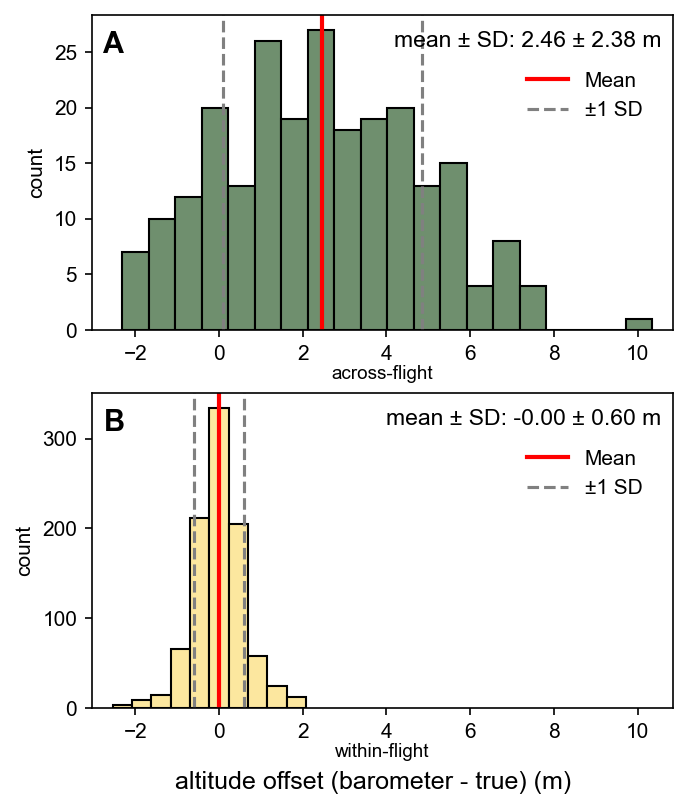

In [14]:
# --- create stacked figure with x-axis subtitles ---
fig, axes = plt.subplots(2, 1, figsize=(5, 6), dpi=150)  # no sharex

# --- determine common x-axis limits --- 
x_min = min(df_flight_summary['mean_altitude_offset_m'].min(), df_cal['altitude_diff_centered'].min()) - 0.5 
x_max = max(df_flight_summary['mean_altitude_offset_m'].max(), df_cal['altitude_diff_centered'].max()) + 0.5

# ---- Panel A: Across-flight mean offsets ----
axes[0].hist(df_flight_summary['mean_altitude_offset_m'], bins=20,
             color='#6f8f6e', edgecolor='black')
axes[0].axvline(across_mean, color='red', linestyle='-', linewidth=2, label='Mean')
axes[0].axvline(across_mean + across_std, color='gray', linestyle='--', linewidth=1.5, label='±1 SD')
axes[0].axvline(across_mean - across_std, color='gray', linestyle='--', linewidth=1.5)

axes[0].set_ylabel('count')
axes[0].set_xlim(x_min, x_max)
axes[0].text(0.02, 0.95, 'A', transform=axes[0].transAxes,
             fontsize=14, fontweight='bold', va='top', ha='left')
axes[0].text(0.98, 0.95,
             f"mean ± SD: {across_mean:.2f} ± {across_std:.2f} m",
             transform=axes[0].transAxes,
             fontsize=11, va='top', ha='right')
axes[0].legend(frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.88))
axes[0].grid(False)
axes[0].text(0.5, -0.11, "across-flight", transform=axes[0].transAxes,
             fontsize=9, ha='center', va='top')

# ---- Panel B: Within-flight residuals ----
axes[1].hist(df_cal['altitude_diff_centered'], bins=10,
             color='#fce79f', edgecolor='black')
axes[1].axvline(within_mean, color='red', linestyle='-', linewidth=2, label='Mean')
axes[1].axvline(within_mean + within_std, color='gray', linestyle='--', linewidth=1.5, label='±1 SD')
axes[1].axvline(within_mean - within_std, color='gray', linestyle='--', linewidth=1.5)

axes[1].set_ylabel('count')
axes[1].set_xlim(x_min, x_max)
axes[1].text(0.02, 0.95, 'B', transform=axes[1].transAxes,
             fontsize=14, fontweight='bold', va='top', ha='left')
axes[1].text(0.98, 0.95,
             f"mean ± SD: {within_mean:.2f} ± {within_std:.2f} m",
             transform=axes[1].transAxes,
             fontsize=11, va='top', ha='right')
axes[1].legend(frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.88))
axes[1].grid(False)
axes[1].text(0.5, -0.11, "within-flight", transform=axes[1].transAxes,
             fontsize=9, ha='center', va='top')

# shared x-axis label
fig.text(0.5, 0.02, "altitude offset (barometer - true) (m)", ha='center', fontsize=12)

# adjust vertical spacing manually
plt.subplots_adjust(hspace=0.20)  # smaller space between panels

plt.show()


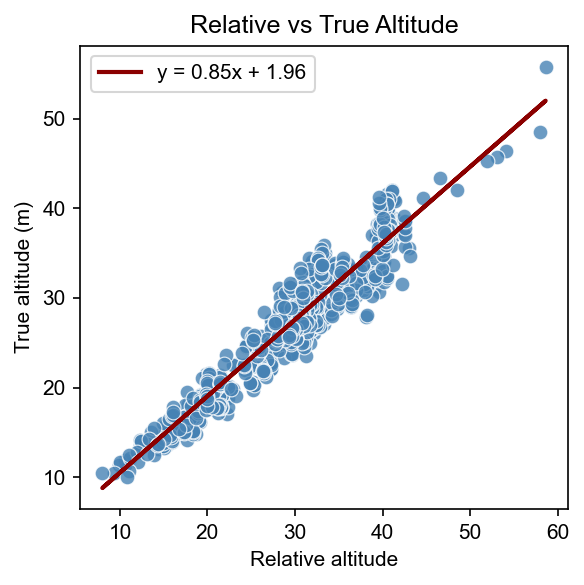

In [15]:
# Fit regression line
slope, intercept = np.polyfit(df_cal["relative_altitude"], df_cal["true_altitude_m"], 1)
line = slope * df_cal["relative_altitude"] + intercept

# Plot
plt.figure(figsize=(4, 4), dpi=150)
sns.scatterplot(
    data=df_cal,
    x="relative_altitude", 
    y="true_altitude_m",
    color="steelblue", s=50, edgecolor="w", alpha=0.8
)

# Regression line
plt.plot(df_cal["relative_altitude"], line, color="darkred", linewidth=2,
         label=f"y = {slope:.2f}x + {intercept:.2f}")

# Labels and style
plt.xlabel("Relative altitude")
plt.ylabel("True altitude (m)")
plt.title("Relative vs True Altitude")
plt.legend()
plt.tight_layout()
plt.show()


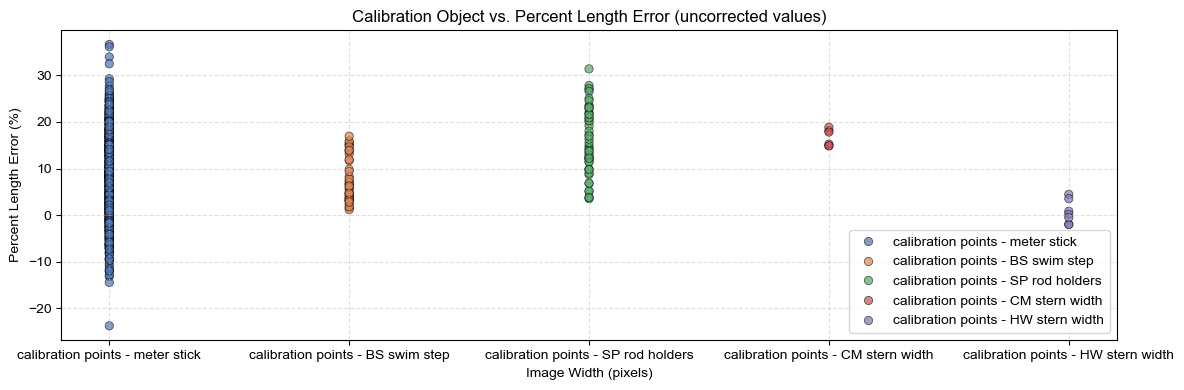

In [16]:
plt.figure(figsize=(12, 4))
sns.scatterplot(data=df_cal, x='label', y='signed_percent_length_error', hue='label', palette='deep', edgecolor='k', alpha=0.7)
plt.xlabel('Image Width (pixels)')
plt.ylabel('Percent Length Error (%)')
plt.title('Calibration Object vs. Percent Length Error (uncorrected values)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Global Offset
Mean-centering altitude errors: removing systematic barometer bias (~2.5m overestimation)

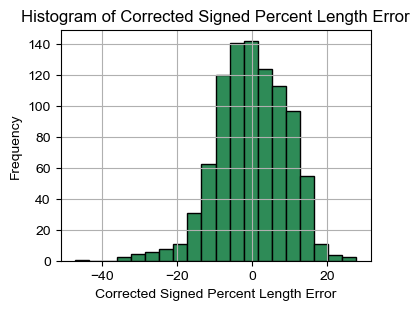

Average altitude overestimation: 2.48 meters
Average % length error using global offset of 2.48m: 7.58%


In [17]:
altitude_bias = df_cal['altitude_diff_m'].mean()
df_fixedcal = df_cal.copy()
df_fixedcal['fixed_offset_altitude'] = df_fixedcal['relative_altitude'] - altitude_bias

df_fixedcal['fixed_gsd_cm_per_pixel'] = (df_fixedcal['fixed_offset_altitude'] * sensor_width_mm * 100) / (focal_length_mm * df_fixedcal['image_width'])
df_fixedcal['fixed_photog_length_cm'] = df_fixedcal['length_pixels'] * df_fixedcal['fixed_gsd_cm_per_pixel']

df_fixedcal['signed_fixed_percent_length_error'] = (df_fixedcal['fixed_photog_length_cm'] - df_fixedcal['true_length_cm']) / df_fixedcal['true_length_cm'] * 100
df_fixedcal['fixed_percent_length_error'] = np.abs(df_fixedcal['fixed_photog_length_cm'] - df_fixedcal['true_length_cm']) / df_fixedcal['true_length_cm'] * 100

plt.figure(figsize=(4, 3))
plt.hist(df_fixedcal['signed_fixed_percent_length_error'], bins=20, color='seagreen', edgecolor='black')
plt.xlabel('Corrected Signed Percent Length Error')
plt.ylabel('Frequency')
plt.title('Histogram of Corrected Signed Percent Length Error')
plt.grid(True)
plt.show()

avg_corr_error = df_fixedcal['fixed_percent_length_error'].mean()
print(f"Average altitude overestimation: {altitude_bias:.2f} meters")
print(f"Average % length error using global offset of {altitude_bias:.2f}m: {avg_corr_error:.2f}%")

# Group-specific offset
Flight-date specific offsets

In [18]:
# compute flight-date calibration
calib_corrections = compute_group_calibrations(df_cal)

# merge group correction back into calibration data
df_groupcal = apply_altitude_calibration(df_cal, calib_corrections)
df_groupcal['corrected_gsd_cm'] = (df_groupcal['corrected_relative_altitude'] * sensor_width_mm * 100) / (focal_length_mm * df_groupcal['image_width'])
df_groupcal['corrected_photog_length_cm'] = (df_groupcal['length_pixels'] * df_groupcal['corrected_gsd_cm'])
df_groupcal['corrected_percent_length_error'] = (np.abs(df_groupcal['corrected_photog_length_cm'] - df_groupcal['true_length_cm'])/ df_groupcal['true_length_cm'] * 100)

# Within-Flight Barometric Drift
Justification for flight-date groupings; less barometric drift within flights than across flights

In [19]:
time_span = df_cal.groupby('flight_date')['date_time'].agg(['min', 'max'])
time_span['duration_min'] = (time_span['max'] - time_span['min']).dt.total_seconds() / 60

# keep only those with >= 5 min span
timespan_calib = 5
valid_flights = time_span[time_span['duration_min'] >= timespan_calib].index.tolist()

# filter df_cal to just those valid flight_dates
df_drift_check = df_cal[df_cal['flight_date'].isin(valid_flights)].copy()

print(f"Number of qualifying flight-dates: {len(valid_flights)}")

mean_val = time_span[time_span['duration_min'] >= timespan_calib]['duration_min'].mean()
sd_val = time_span[time_span['duration_min'] >= timespan_calib]['duration_min'].std()
print(f"mean ± sd: {mean_val:.2f} ± {sd_val:.2f}")

time_span[time_span['duration_min'] >= timespan_calib]

Number of qualifying flight-dates: 6
mean ± sd: 11.36 ± 4.39


,min,max,duration_min
flight_date,,,
flight3-2022-08-22,2022-08-22 14:42:55,2022-08-22 14:54:55,12.000000
flight3-2023-11-06,2023-11-06 10:38:55,2023-11-06 10:46:13,7.300000
flight3-2024-09-09,2024-09-09 15:15:57,2024-09-09 15:29:50,13.883333
flight7-2022-08-22,2022-08-22 16:13:07,2022-08-22 16:23:07,10.000000
flight7-2024-06-25,2024-06-25 15:54:27,2024-06-25 16:01:06,6.650000
flight8-2024-11-29,2024-11-29 15:07:36,2024-11-29 15:25:57,18.350000


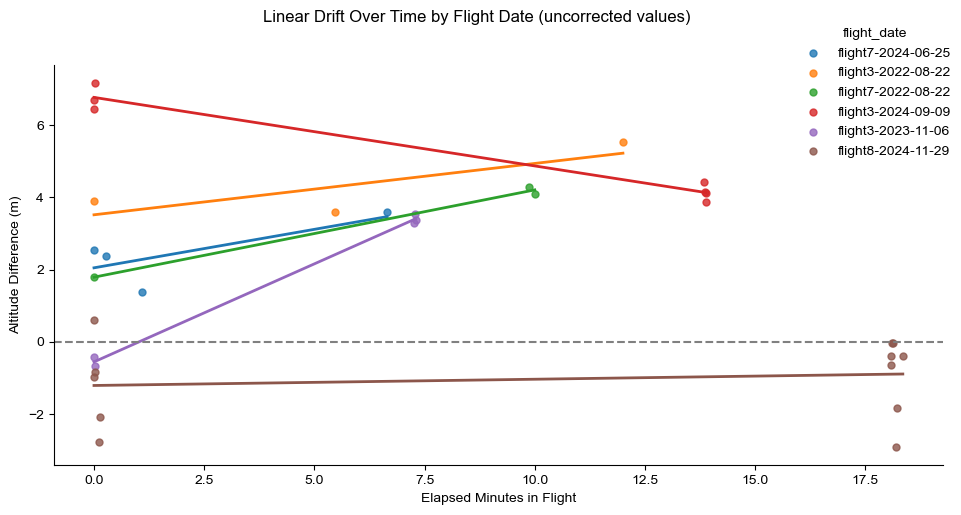

Mean-centered residuals (drift check): 0.00 m
Standard deviation within (drift check): 1.27 m
Standard deviation across (drift check): 2.21 m
Standard deviation within (all flights): 0.60 m
Variance ratio - (drift check within / drift check across): 0.33
Variance ratio - all (within / across): 0.06


In [20]:
df_drift_check['elapsed_min'] = df_drift_check.groupby('flight_date')['date_time'].transform(lambda x: (x - x.min()).dt.total_seconds() / 60)
g = sns.lmplot(data=df_drift_check,x='elapsed_min', y='altitude_diff_m',hue='flight_date', height=5, aspect=1.6,scatter_kws={'s': 25},line_kws={'linewidth': 2},ci=None)
g.ax.axhline(0, linestyle='--', color='gray')
g.set_axis_labels('Elapsed Minutes in Flight', 'Altitude Difference (m)')
g.fig.suptitle('Linear Drift Over Time by Flight Date (uncorrected values)', y=1.02)
g._legend.set_bbox_to_anchor((1, 1))
g._legend.set_loc('upper right')
plt.tight_layout()
plt.show()

# get std of all drift check within-flight residuals
df_drift_check['altitude_diff_centered'] = df_drift_check['altitude_diff_m'] - df_drift_check.groupby('flight_date')['altitude_diff_m'].transform('mean')
within_std_driftcheck = df_drift_check['altitude_diff_centered'].std()
within_mean_driftcheck = df_drift_check['altitude_diff_centered'].mean()

# get std of all drift check across-flight 
df_flight_summary_driftcheck = df_flight_summary[df_flight_summary['flight_date'].isin(valid_flights)].copy()
across_mean_driftcheck = df_flight_summary_driftcheck['mean_altitude_offset_m'].mean()
across_std_driftcheck = df_flight_summary_driftcheck['mean_altitude_offset_m'].std()

# summary values
print(f"Mean-centered residuals (drift check): {within_mean_driftcheck:.2f} m")
print(f"Standard deviation within (drift check): {within_std_driftcheck:.2f} m")
print(f"Standard deviation across (drift check): {across_std_driftcheck:.2f} m") # check for across flights
print(f"Standard deviation within (all flights): {within_std:.2f} m") # check for across flights
print(f"Variance ratio - (drift check within / drift check across): {within_std_driftcheck**2 / across_std_driftcheck**2:.2f}") 
print(f"Variance ratio - all (within / across): {within_std**2 / across_std**2:.2f}") 

# Within-Flight Altitude Effects
Does altitude of calibration imagery impact accuracy (% TL)

In [21]:
# now check altitude gaps 
altitude_gaps = df_cal.groupby('flight_date')['relative_altitude'].agg(['max', 'min']).reset_index()
altitude_gaps['altitude_gap'] = altitude_gaps['max'] - altitude_gaps['min']

# filter to 30-40m flights
altitude_gaps = altitude_gaps[altitude_gaps['min'] > 0]
altitude_gaps = altitude_gaps[altitude_gaps['max'] < 100]

# filter flight_dates with altitude gap > 10 m
flight_dates_large_gap = altitude_gaps[altitude_gaps['altitude_gap'] > 10]['flight_date']
df_alt_gap = df_cal[df_cal['flight_date'].isin(flight_dates_large_gap)]

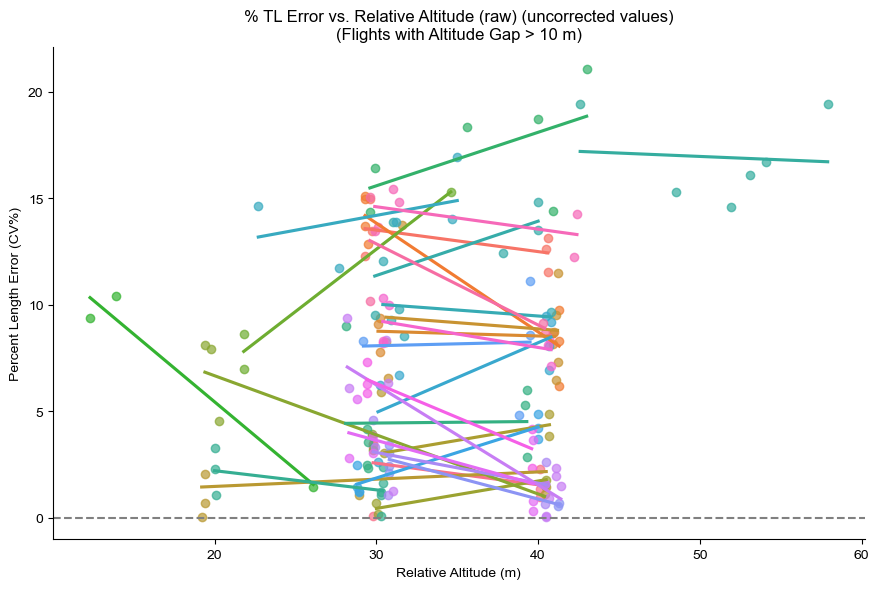

In [22]:
g = sns.lmplot(data=df_alt_gap, x='relative_altitude', y='percent_length_error', hue='flight_date', 
               height=6, aspect=1.2, markers='o', scatter_kws={'alpha':0.7}, ci=None)

g._legend.remove()
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Relative Altitude (m)')
plt.ylabel('Percent Length Error (CV%)')
plt.title('% TL Error vs. Relative Altitude (raw) (uncorrected values)\n(Flights with Altitude Gap > 10 m)')
plt.tight_layout()
plt.show()

In [23]:
pearson_r, pearson_p = pearsonr(df_alt_gap['relative_altitude'], df_alt_gap['altitude_diff_m'])
spearman_r, spearman_p = spearmanr(df_alt_gap['relative_altitude'], df_alt_gap['altitude_diff_m'])
slope, intercept, r_value, p_value, std_err = linregress(df_alt_gap['relative_altitude'], df_alt_gap['altitude_diff_m'])

print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.3f})")
print(f"Spearman r = {spearman_r:.3f} (p = {spearman_p:.3f})")
print(f"Linear model: altitude_diff_m = {slope:.3f} * relative_altitude + {intercept:.3f}")
print(f"R² = {r_value**2:.3f}")
print(f"p = {p_value:.3e}")

Pearson r = 0.492 (p = 0.000)
Spearman r = 0.422 (p = 0.000)
Linear model: altitude_diff_m = 0.158 * relative_altitude + -3.675
R² = 0.242
p = 6.160e-12


# Measurement Error - Theoretical Data Accuracy (TL %)

In [24]:
# define body depth uncertainty (m)
bodydepth_mean = 1.0 
bodydepth_std = 0.25

# combine within-flight altitude error + body depth error in quadrature (H uncertainty)
photog_std = np.sqrt(within_std**2 + bodydepth_std**2)
photog_std_cm = photog_std*100

# error propagation: GSD std introduced by H uncertainty
df_photog['GSD_std_cm'] = (
    sensor_width_mm / (focal_length_mm * df_photog['image_width'])) * photog_std_cm

# define mask prediction uncertainty (m)
df_photog['mask_error_cm'] = (df_photog['TL_skel_cm'] - df_photog['TL_cm'])
segment_std = df_photog['mask_error_cm'].std()

# overall GSD std including segmentation error (affecting TL_pixels)
df_photog['TL_std_cm'] = np.sqrt(
    (df_photog['TL_skel_pixels'] * df_photog['GSD_std_cm'])**2 +
    (segment_std)**2)

print(f"Within-flight altitude std: ±{within_std:.2f} m")
print(f"Body depth effective H std: ±{bodydepth_std:.2f} m")
print(f"Combined effictive H std: ±{photog_std:.2f} m")
print(f"Mean photogrammetric TL error (GSD only): {df_photog['GSD_std_cm'].mean():.3f} ± {df_photog['GSD_std_cm'].std():.3f} cm")
print(f"Segmentation error (1σ): {segment_std:.2f} cm")
print(f"Overall TL error including segmentation: {df_photog['TL_std_cm'].mean():.2f} ± {df_photog['TL_std_cm'].std():.2f} cm")


Within-flight altitude std: ±0.60 m
Body depth effective H std: ±0.25 m
Combined effictive H std: ±0.65 m
Mean photogrammetric TL error (GSD only): 0.024 ± 0.008 cm
Segmentation error (1σ): 7.79 cm
Overall TL error including segmentation: 11.73 ± 2.85 cm


In [25]:
# reporting relative contributions
df_errorsum = df_photog.copy() 
gsd_factor = (sensor_width_mm / (focal_length_mm * df_errorsum['image_width'])) * 100

# calculate GSD std from each photogrammetric source separately (cm)
df_errorsum['GSD_std_within_cm'] = gsd_factor * within_std
df_errorsum['GSD_std_bodydepth_cm'] = gsd_factor * bodydepth_std

# propagate to TL uncertainty individually
df_errorsum['TL_std_within_cm'] = df_errorsum['TL_skel_pixels'] * df_errorsum['GSD_std_within_cm']
df_errorsum['TL_std_bodydepth_cm'] = df_errorsum['TL_skel_pixels'] * df_errorsum['GSD_std_bodydepth_cm']

# segmentation std 
segment_std_cm = segment_std
df_errorsum['TL_std_segmentation_cm'] = segment_std_cm

# combine
df_errorsum['TL_std_photogrammetry_cm'] = np.sqrt(
    df_errorsum['TL_std_within_cm']**2 + df_errorsum['TL_std_bodydepth_cm']**2)
df_errorsum['TL_std_total_cm'] = np.sqrt(
    df_errorsum['TL_std_photogrammetry_cm']**2 + df_errorsum['TL_std_segmentation_cm']**2)

# summarize means and relative contributions
mean_within = df_errorsum['TL_std_within_cm'].mean()
mean_bodydepth = df_errorsum['TL_std_bodydepth_cm'].mean()
mean_segmentation = df_errorsum['TL_std_segmentation_cm'].mean()
mean_photogrammetry = df_errorsum['TL_std_photogrammetry_cm'].mean()
mean_total = df_errorsum['TL_std_total_cm'].mean()

print("Mean TL uncertainty contributions (1σ, in cm):")
print(f"  • Within-flight altitude variability: ±{mean_within:.2f} cm")
print(f"  • Body depth uncertainty:             ±{mean_bodydepth:.2f} cm")
print(f"  • Mask segmentation error:            ±{mean_segmentation:.2f} cm")
print(f"  → Photogrammetric (within + depth):  ±{mean_photogrammetry:.2f} cm")
print(f"  → Total combined TL uncertainty:      ±{mean_total:.2f} cm\n")

# compute the variances (squared stds)
var_within = (df_errorsum['TL_std_within_cm']**2).mean()
var_bodydepth = (df_errorsum['TL_std_bodydepth_cm']**2).mean()
var_segmentation = (df_errorsum['TL_std_segmentation_cm']**2).mean()

# total variance = sum of variances
var_total = var_within + var_bodydepth + var_segmentation

# compute relative contributions (in %)
rel_within = 100 * var_within / var_total
rel_bodydepth = 100 * var_bodydepth / var_total
rel_segmentation = 100 * var_segmentation / var_total

print("Relative contributions to total TL uncertainty:")
print(f"  • Within-flight altitude: {rel_within:.1f}%")
print(f"  • Body depth:             {rel_bodydepth:.1f}%")
print(f"  • Segmentation:           {rel_segmentation:.1f}%")

Mean TL uncertainty contributions (1σ, in cm):
  • Within-flight altitude variability: ±7.83 cm
  • Body depth uncertainty:             ±3.27 cm
  • Mask segmentation error:            ±7.79 cm
  → Photogrammetric (within + depth):  ±8.49 cm
  → Total combined TL uncertainty:      ±11.73 cm

Relative contributions to total TL uncertainty:
  • Within-flight altitude: 49.7%
  • Body depth:             8.6%
  • Segmentation:           41.7%


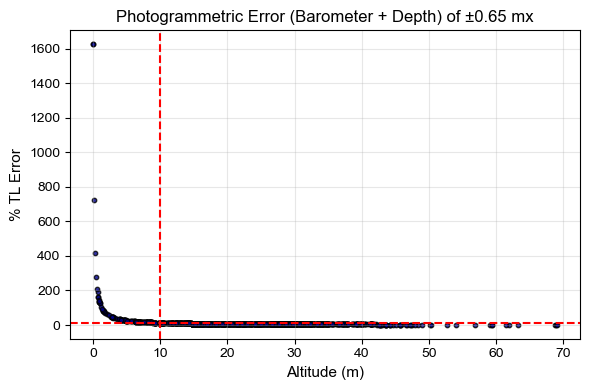

In [26]:
# use df_gimbal (pre-altitude filtering) to justify altitude cutoff 
df_pixels = df_pixels.copy()

shark_length_cm = 300   # Assume constant TL of 300 cm
altitude_error_m = photog_std  # barometer + depth error
err_cm = altitude_error_m * 100

# pull altitude and image width for shark images
alt_cm = df_pixels["corrected_relative_altitude"].values * 100  # Convert to cm
image_width_px = df_pixels["image_width"].values
scaling_factor = sensor_width_mm / focal_length_mm

# gsd calculations
gsd_base = scaling_factor * (alt_cm / image_width_px)
gsd_low = scaling_factor * ((alt_cm - err_cm) / image_width_px)
gsd_high = scaling_factor * ((alt_cm + err_cm) / image_width_px)

# Compute percent error due to altitude uncertainty
percent_error = np.abs(gsd_high - gsd_low) / gsd_base * 100
df_pixels['theoretical_percent_TL_error_H'] = percent_error

plt.figure(figsize=(6, 4))
plt.scatter(df_pixels["corrected_relative_altitude"], df_pixels["theoretical_percent_TL_error_H"], color="darkblue", edgecolor="k", alpha=0.8, s=10)

plt.axvline(x=altitude_threshold, color='red', linestyle='--', linewidth=1.5, label=f"{altitude_threshold} m threshold") # cutoff altitude
plt.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label="10% TL error threshold") # +-TL error 

plt.xlabel("Altitude (m)", fontsize=11)
plt.ylabel("% TL Error", fontsize=11)
plt.title(f"Photogrammetric Error (Barometer + Depth) of ±{photog_std:.2f} mx", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# create df_pixels_sorted
df_pixels_sorted = df_pixels.sort_values("corrected_relative_altitude").reset_index(drop=True)
df_pixels_sorted['cumulative_n'] = np.arange(1, len(df_pixels_sorted) + 1)


In [28]:
# get the curve (%TL error vs altitude)
x = df_pixels_sorted["corrected_relative_altitude"].values
y = df_pixels_sorted["theoretical_percent_TL_error_H"].values

# find knee/elbow (look for convex, increasing curve)
knee = KneeLocator(x, y, curve="convex", direction="increasing")
elbow_altitude = knee.knee

print(f"Elbow identified at ~{elbow_altitude:.2f} m")

Elbow identified at ~69.01 m


Elbow identified at ~2.33 m


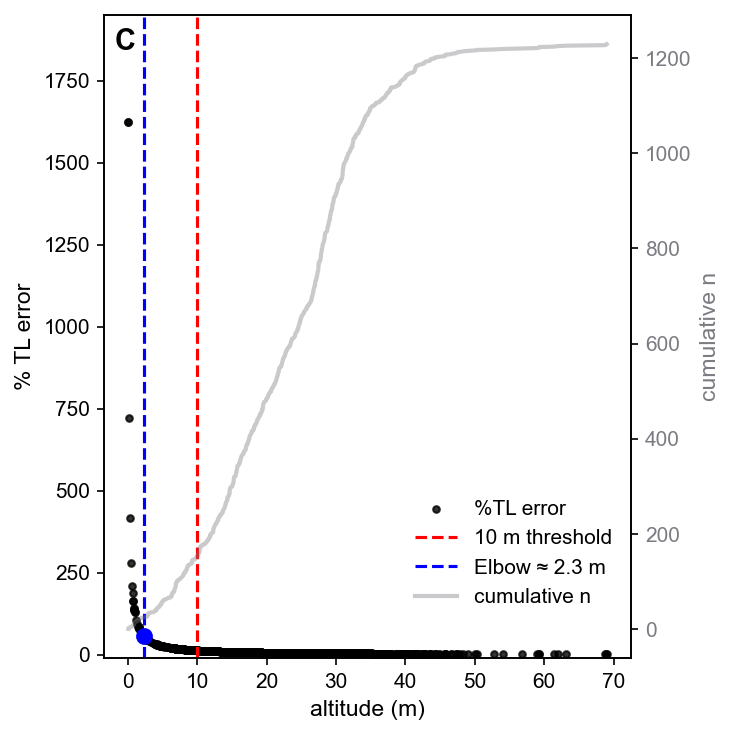

In [29]:
# get the curve (%TL error vs altitude)
x = df_pixels_sorted["corrected_relative_altitude"].values
y = df_pixels_sorted["theoretical_percent_TL_error_H"].values

# find knee/elbow (convex, decreasing)
knee = KneeLocator(x, y, curve="convex", direction="decreasing")
elbow_altitude = knee.knee

print(f"Elbow identified at ~{elbow_altitude:.2f} m")

# plot
fig, ax1 = plt.subplots(figsize=(5, 5), dpi=150)

# --- cumulative n in background on secondary y-axis ---
ax2 = ax1.twinx()
ax2.plot(df_pixels_sorted["corrected_relative_altitude"], 
         df_pixels_sorted["cumulative_n"], 
         color="#7B7B82", linewidth=2, alpha=0.4, label="cumulative n", zorder=0)
ax2.set_ylabel("cumulative n", fontsize=11, color="#7B7B82")
ax2.tick_params(axis='y', labelcolor="#7B7B82")

# --- scatter %TL error vs altitude ---
ax1.scatter(x, y, color="black", edgecolor="k",
            alpha=0.8, s=10, label="%TL error", zorder=5)

# --- vertical threshold line ---
ax1.axvline(x=altitude_threshold, color='red', linestyle='--', linewidth=1.5,
            label=f"{altitude_threshold} m threshold", zorder=6)

# --- mark elbow point in blue ---
if elbow_altitude is not None:
    ax1.axvline(x=elbow_altitude, color="blue", linestyle='--', linewidth=1.5,
                label=f"Elbow ≈ {elbow_altitude:.1f} m", zorder=6)
    ax1.scatter(elbow_altitude, y[list(x).index(elbow_altitude)], color="blue", s=50, zorder=7)

# --- labels and title ---
ax1.set_xlabel("altitude (m)", fontsize=11)
ax1.set_ylabel("% TL error", fontsize=11)

# extend Y-axis for room for 'C'
y_max = max(y) * 1.2  # 20% extra space
ax1.set_ylim(-10, y_max)

#plt.title(f"Photogrammetric Error (Barometer + Depth) of ±{photog_std:.2f} m", fontsize=12)

# --- add "C" in upper left ---
ax1.text(0.02, 0.98, 'C', transform=ax1.transAxes,
         fontsize=14, fontweight='bold', va='top', ha='left')

# --- remove grid ---
ax1.grid(False)

# --- combine legends from both axes ---
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles=handles1 + handles2,
           labels=labels1 + labels2,
           loc='lower right', fontsize=10,
           bbox_to_anchor=(1.0, 0.05),
           frameon=False)

fig.tight_layout()
plt.show()


In [30]:
df_pixels = df_pixels.sort_values("corrected_relative_altitude")

# Find first altitude where error <= 10
threshold_error = 10
candidate_altitudes = df_pixels[df_pixels["theoretical_percent_TL_error_H"] <= threshold_error]
sugg_threshold = candidate_altitudes["corrected_relative_altitude"].min()

print(f"Suggested altitude threshold: {sugg_threshold:.1f} m")


Suggested altitude threshold: 13.1 m


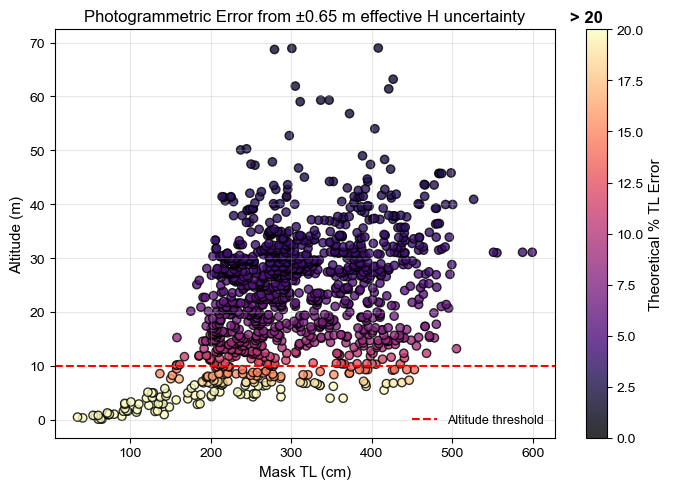

In [31]:
#pull corrected altitude and shark TL (in cm) from df_pixels
altitude_cm = df_pixels["corrected_relative_altitude"] * 100
shark_cm = df_pixels["TL_skel_cm"]

# calculate GSD at base, low, and high altitude (from photog uncertainty)
gsd_base = scaling_factor * altitude_cm
gsd_low = scaling_factor * (altitude_cm - photog_std_cm)
gsd_high = scaling_factor * (altitude_cm + photog_std_cm)

# estimate TL using pixel count and adjusted GSDs
pixel_length = shark_cm / gsd_base
est_low = pixel_length * gsd_low
est_high = pixel_length * gsd_high

# calculate ± % TL error
percent_error = np.abs(est_high - est_low) / shark_cm * 100
percent_error[altitude_cm < 0] = 1000  # extreme placeholder for invalid altitudes
df_pixels["photog_theoretical_percent_TL_error_H"] = percent_error

# plot
capped_error = df_pixels["photog_theoretical_percent_TL_error_H"].clip(upper=20)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df_pixels["TL_skel_cm"], df_pixels["corrected_relative_altitude"], c=capped_error,
    cmap="magma",vmin=0,vmax=20,edgecolor="k",alpha=0.8)

# color bar
cbar = plt.colorbar(scatter)
cbar.set_label("Theoretical % TL Error", fontsize=11)
cbar.ax.text(-0.8, 1.01, "> 20", transform=cbar.ax.transAxes,
             fontsize=12, fontweight="bold", va="bottom", ha="left")

# altitude threshold
plt.axhline(y=altitude_threshold, color='red', linestyle='--', linewidth=1.5,
            label='Altitude threshold')

plt.xlabel("Mask TL (cm)", fontsize=11)
plt.ylabel("Altitude (m)", fontsize=11)
plt.title(f"Photogrammetric Error from ±{photog_std:.2f} m effective H uncertainty", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc="lower right", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()


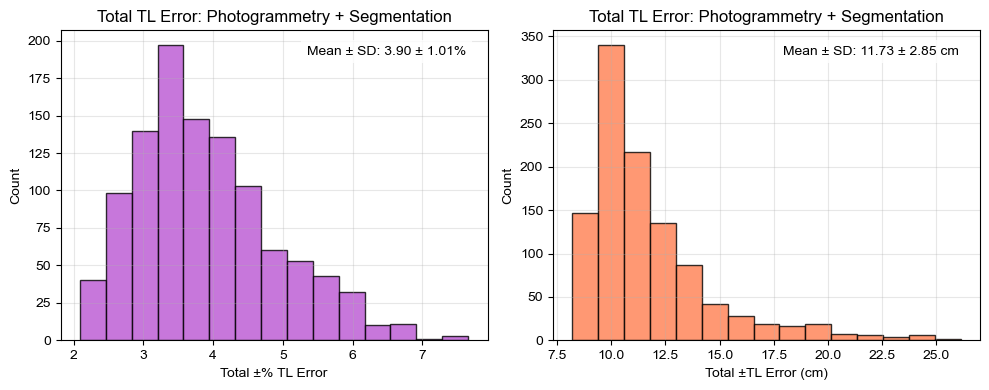

In [32]:
# Copy df_errorsum and prepare columns
df_plot = df_errorsum.copy()

# calculate ± % TL error from total cm uncertainty
df_plot["TL_error_percent"] = (df_plot["TL_std_total_cm"] / df_plot["TL_skel_cm"]) * 100
df_plot["TL_error_plusminus_cm"] = df_plot["TL_std_total_cm"]  # already 1σ

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# histogram of ±% TL error
axes[0].hist(df_plot["TL_error_percent"], bins=15, edgecolor='k', alpha=0.8, color='mediumorchid')
axes[0].set_xlabel('Total ±% TL Error')
axes[0].set_ylabel('Count')
axes[0].set_title('Total TL Error: Photogrammetry + Segmentation')
axes[0].grid(alpha=0.3)

mean_pct = df_plot["TL_error_percent"].mean()
std_pct = df_plot["TL_error_percent"].std()
stats_text_pct = f'Mean ± SD: {mean_pct:.2f} ± {std_pct:.2f}%'
axes[0].text(0.95, 0.95, stats_text_pct, transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Histogram of ±TL error in cm
axes[1].hist(df_plot["TL_error_plusminus_cm"], bins=15, edgecolor='k', alpha=0.8, color='coral')
axes[1].set_xlabel('Total ±TL Error (cm)')
axes[1].set_ylabel('Count')
axes[1].set_title('Total TL Error: Photogrammetry + Segmentation')
axes[1].grid(alpha=0.3)

mean_cm = df_plot["TL_error_plusminus_cm"].mean()
std_cm = df_plot["TL_error_plusminus_cm"].std()
stats_text_cm = f'Mean ± SD: {mean_cm:.2f} ± {std_cm:.2f} cm'
axes[1].text(0.95, 0.95, stats_text_cm, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.show()


# Measurement Error - Real Data Precision (TL%)

In [33]:
def compute_cv_summary(df, minflights):
    # compute corrected and uncorrected shark TL
    df = df.copy()
    df.loc[:, 'TL_cm_corrected'] = (
        df['TL_skel_pixels'] * (df['corrected_relative_altitude'] * sensor_width_mm * 100)
        / (focal_length_mm * df['image_width']))

    # filter to sharks with >= minflights flights
    flight_counts = df.groupby('White.Shark.ID')['flight_date'].nunique()
    sharks_multiflight = flight_counts[flight_counts >= minflights].index
    df_multiflight_sharks = df[df['White.Shark.ID'].isin(sharks_multiflight)]

    # within flight CV
    within_flight_cv = (
        df_multiflight_sharks.groupby(['White.Shark.ID', 'flight_date'])
        .agg(TL_cm_corrected_mean=('TL_cm_corrected', 'mean'),
            TL_cm_corrected_std=('TL_cm_corrected', 'std'),
            n_obs=('TL_cm_corrected', 'count')).reset_index())

    within_flight_cv['CV_corrected'] = within_flight_cv['TL_cm_corrected_std'] / within_flight_cv['TL_cm_corrected_mean']

    # across flight CV
    mean_tl_per_flight = (
        df_multiflight_sharks.groupby(['White.Shark.ID', 'flight_date'])
        .agg(TL_cm_corrected_mean=('TL_cm_corrected', 'mean')).reset_index())

    across_flight_cv = (
        mean_tl_per_flight.groupby('White.Shark.ID')
        .agg(CV_corrected_across=('TL_cm_corrected_mean', lambda x: np.std(x) / np.mean(x)),
            n_flights=('flight_date', 'nunique')).reset_index())

    # average within-flight CV per shark
    within_cv_summary = (
        within_flight_cv.groupby('White.Shark.ID')
        .agg(CV_corrected_within=('CV_corrected', 'mean'),
            n_within_flights=('flight_date', 'nunique')).reset_index())

    # Merge within and across CV summary
    cv_summary = pd.merge(within_cv_summary, across_flight_cv, on='White.Shark.ID')

    # Add a column for minflights used
    cv_summary['minflights'] = minflights

    return cv_summary, mean_tl_per_flight

# produce for 2 flights and 3 flights
cv_summary_3, mean_tl_per_flight_3 = compute_cv_summary(df_photog, minflights=3)
cv_summary_2, mean_tl_per_flight_2 = compute_cv_summary(df_photog, minflights=2)


/var/folders/7d/j70l7sts6394lsmftn02krl80000gn/T/ipykernel_64504/2718515141.py:11: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df_long, x='Variability', y='CV', color='lightblue',


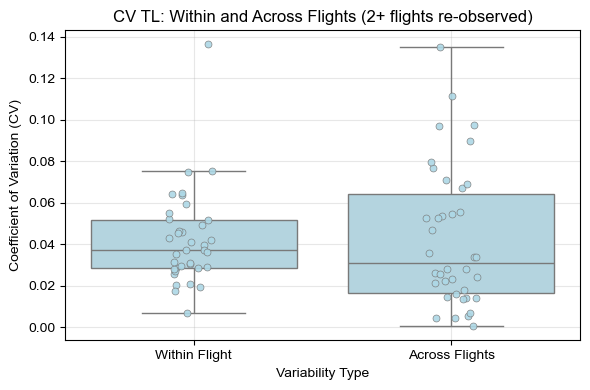

Across Flights: mean = 4.28%, SD = 3.35% (mean ± SD = 4.28 ± 3.35%, n = 38)
Within Flight: mean = 4.25%, SD = 2.26% (mean ± SD = 4.25 ± 2.26%, n = 37)


In [34]:
df_long = pd.melt(cv_summary_2,id_vars=['White.Shark.ID'],
    value_vars=['CV_corrected_within', 'CV_corrected_across'],
    var_name='Variable',value_name='CV')

df_long['Variability'] = df_long['Variable'].apply(
    lambda x: 'Within Flight' if 'within' in x else 'Across Flights')

plt.figure(figsize=(6, 4))
sns.boxplot(data=df_long, x='Variability', y='CV', color='lightblue',
    showfliers=False, linewidth=1, saturation=0.75)
sns.stripplot(data=df_long, x='Variability', y='CV', color='lightblue',
    jitter=0.1, alpha=0.9, edgecolor='gray', linewidth=0.5, marker='o')

plt.legend([], [], frameon=False)

plt.title('CV TL: Within and Across Flights (2+ flights re-observed)')
plt.ylabel('Coefficient of Variation (CV)')
plt.xlabel('Variability Type')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# print stats
group_stats = df_long.groupby('Variability')['CV'].agg(['mean', 'std', 'count']).reset_index()
for _, row in group_stats.iterrows():
    print(f"{row['Variability']}: mean = {row['mean']*100:.2f}%, SD = {row['std']*100:.2f}% "
          f"(mean ± SD = {row['mean']*100:.2f} ± {row['std']*100:.2f}%, n = {int(row['count'])})")


# Shark Summary Stats for Correction

In [35]:
# Compute corrected and uncorrected TL if not already present
df_altitudecorr = df_photog.copy()
df_altitudecorr['TL_cm_uncorrected'] = (df_altitudecorr['TL_skel_pixels'] * (df_altitudecorr['relative_altitude'] * sensor_width_mm * 100)/ (focal_length_mm * df_photog['image_width']))

# Compute mean TL per shark
mean_tl_per_shark = df_altitudecorr.groupby('White.Shark.ID').agg(
    TL_cm_corrected_mean=('TL_skel_cm', 'mean'),TL_cm_uncorrected_mean=('TL_cm_uncorrected', 'mean'),
    n_obs=('TL_skel_cm', 'count')).reset_index()

# per-shark differences
mean_tl_per_shark['TL_diff_cm'] = mean_tl_per_shark['TL_cm_corrected_mean'] - mean_tl_per_shark['TL_cm_uncorrected_mean']

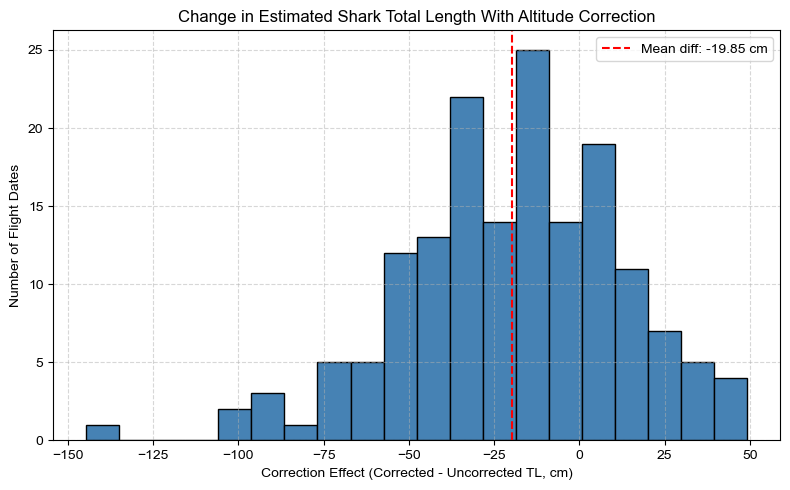

Mean difference (Corrected - Uncorrected TL): -19.85 cm ± 32.13 cm (mean ± SD)


In [36]:
# plot histogram of the differences
plt.figure(figsize=(8, 5))
plt.hist(mean_tl_per_shark['TL_diff_cm'], bins=20, edgecolor='black', color='steelblue')
plt.axvline(mean_tl_per_shark['TL_diff_cm'].mean(), color='red', linestyle='--', label=f"Mean diff: {mean_tl_per_shark['TL_diff_cm'].mean():.2f} cm")
plt.xlabel('Correction Effect (Corrected - Uncorrected TL, cm)')
plt.ylabel('Number of Flight Dates')
plt.title('Change in Estimated Shark Total Length With Altitude Correction')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# summary stats
mean_sharkcm_change = mean_tl_per_shark['TL_diff_cm'].mean()
std_sharkcm_change = mean_tl_per_shark['TL_diff_cm'].std()
print(f"Mean difference (Corrected - Uncorrected TL): {mean_sharkcm_change:.2f} cm ± {std_sharkcm_change:.2f} cm (mean ± SD)")